# Identification and Classification of Cross-outs in Handwritten Documents
**D7047E Advanced Deep Learning | Group 14**

Team: Suresh Balaraman, Nagarajan Ganesan, Chirag Gurumurthy, Shameena Mohammed Nabeel, Lakshmi Shankar Paramasivan

Goals:
1. Binary Classification - Clean vs. Crossed-out
2. Multi-class Identification - 7 styles
3. Generalization on 50 handwritten custom images

## 1. Setup

In [3]:
!pip install -q gdown torch torchvision pillow matplotlib scikit-learn

In [4]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'  # makes CUDA errors report at the actual line

import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Dataset Download and Extraction

In [6]:
try:
    import gdown
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'gdown', '-q'], check=True)
    import gdown

FILE_ID     = '1dgIfz8aFwCuphLN9-L7gcU4QN0UQEKP3'
ZIP_PATH    = 'adl_dataset.zip'
EXTRACT_DIR = 'iam_crossouts'

if not os.path.exists(ZIP_PATH):
    print('Downloading dataset...')
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', ZIP_PATH, quiet=False)
else:
    print('Zip already present, skipping download.')

if not os.path.exists(EXTRACT_DIR):
    print('Extracting ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print('Extraction complete.')
else:
    print('Dataset already extracted.')

Zip already present, skipping download.
Dataset already extracted.


## 3. Dataset Exploration

In [8]:
BASE   = EXTRACT_DIR
SPLITS = ['train', 'val', 'test']
TRAIN_IMG = os.path.join(BASE, 'train', 'images')

categories = sorted(os.listdir(TRAIN_IMG))
print(f'{"Category":<15}', '  '.join(f'{s:>8}' for s in SPLITS))
print('-' * 45)
for cat in categories:
    counts = []
    for split in SPLITS:
        path = os.path.join(BASE, split, 'images', cat)
        counts.append(len(os.listdir(path)) if os.path.exists(path) else 0)
    print(f'{cat:<15}', '  '.join(f'{c:>8,}' for c in counts))

Category           train       val      test
---------------------------------------------
CLEAN             47,997     7,559    20,306
CROSS             47,997     7,559    20,306
DIAGONAL          47,997     7,559    20,306
DOUBLE_LINE       47,997     7,559    20,306
MIXED             47,997     7,559    20,306
SCRATCH           47,997     7,559    20,306
SINGLE_LINE       47,997     7,559    20,306
WAVE              47,997     7,559    20,306
ZIG_ZAG           47,997     7,559    20,306


## 4. Data Preprocessing

Design decisions from project proposal:

| Decision | Choice | Reason |
|---|---|---|
| Resize strategy | Pad then resize | Preserves cross-out geometry: aspect ratio, wave frequency, zig-zag amplitude |
| Pad fill | White (255) | Matches IAM document background |
| Colour mode | Grayscale to 3-channel | Required for ImageNet-pretrained ResNet/ViT |
| Inversion | No | Black ink on white is standard for pretrained CNNs |
| Normalisation | ImageNet mean/std | Standard for transfer learning |

In [10]:
class PadToSquare:
    """Symmetrically pad image to square with white fill, preserving aspect ratio."""
    def __init__(self, fill=255):
        self.fill = fill

    def __call__(self, img):
        w, h = img.size
        max_dim    = max(w, h)
        pad_left   = (max_dim - w) // 2
        pad_top    = (max_dim - h) // 2
        pad_right  = max_dim - w - pad_left
        pad_bottom = max_dim - h - pad_top
        return TF.pad(img, (pad_left, pad_top, pad_right, pad_bottom), fill=self.fill)


IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    PadToSquare(fill=255),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    PadToSquare(fill=255),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

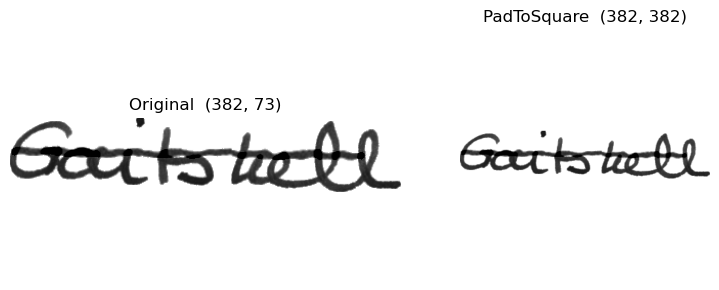

In [11]:
# Visualise padding effect
sample_file = sorted(os.listdir(os.path.join(TRAIN_IMG, 'CLEAN')))[5]

raw    = Image.open(os.path.join(TRAIN_IMG, 'SINGLE_LINE', sample_file))
padded = PadToSquare(fill=255)(raw)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.imshow(raw,    cmap='gray'); ax1.set_title(f'Original  {raw.size}')
ax2.imshow(padded, cmap='gray'); ax2.set_title(f'PadToSquare  {padded.size}')
for ax in (ax1, ax2): ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Dataset and DataLoaders

In [13]:
# MIXED excluded: not one of the 7 defined cross-out styles
CATEGORIES  = ['CLEAN', 'SINGLE_LINE', 'DOUBLE_LINE', 'DIAGONAL', 'CROSS', 'WAVE', 'ZIG_ZAG', 'SCRATCH']
NUM_CLASSES = len(CATEGORIES)
LABEL_MAP   = {cat: i for i, cat in enumerate(CATEGORIES)}
print('Label map:', LABEL_MAP)


class CrossOutDataset(Dataset):
    def __init__(self, base_path, categories, transform=None):
        self.transform = transform
        self.samples   = []
        label_map = {cat: i for i, cat in enumerate(categories)}
        for cat in categories:
            folder = os.path.join(base_path, cat)
            if not os.path.exists(folder):
                print(f'Warning: {folder} not found')
                continue
            for fname in os.listdir(folder):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(folder, fname), label_map[cat]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path)
        if self.transform:
            img = self.transform(img)
        return img, label


train_ds = CrossOutDataset(os.path.join(BASE, 'train', 'images'), CATEGORIES, train_transform)
val_ds   = CrossOutDataset(os.path.join(BASE, 'val',   'images'), CATEGORIES, val_transform)
test_ds  = CrossOutDataset(os.path.join(BASE, 'test',  'images'), CATEGORIES, val_transform)
print(f'Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}')

Label map: {'CLEAN': 0, 'SINGLE_LINE': 1, 'DOUBLE_LINE': 2, 'DIAGONAL': 3, 'CROSS': 4, 'WAVE': 5, 'ZIG_ZAG': 6, 'SCRATCH': 7}
Train: 383,976  Val: 60,472  Test: 162,448


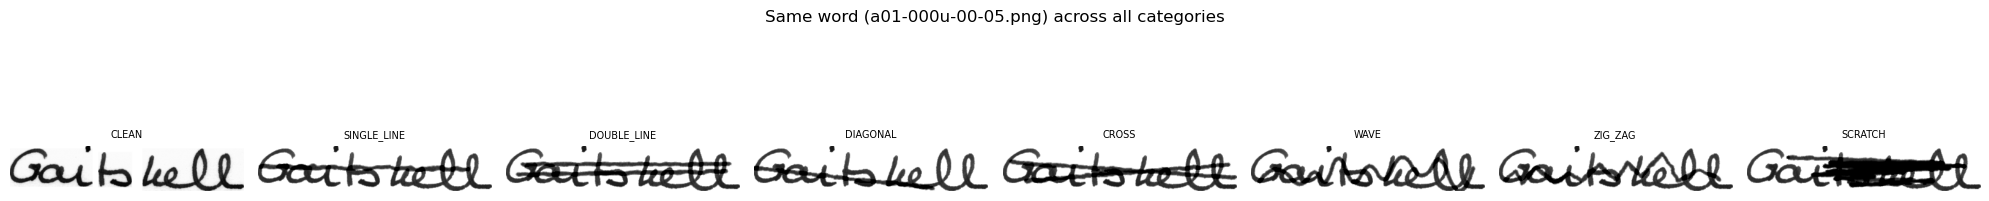

In [14]:
# Same word across all categories
sample_file = sorted(os.listdir(os.path.join(TRAIN_IMG, 'CLEAN')))[5]

fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(20, 3))
for ax, cat in zip(axes, CATEGORIES):
    img = Image.open(os.path.join(TRAIN_IMG, cat, sample_file))
    ax.imshow(img, cmap='gray')
    ax.set_title(cat, fontsize=7)
    ax.axis('off')
plt.suptitle(f'Same word ({sample_file}) across all categories')
plt.tight_layout()
plt.show()


In [15]:
BATCH_SIZE  = 64
NUM_WORKERS = 0

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

imgs, labels = next(iter(train_loader))
print(f'Batch shape: {imgs.shape} | Sample labels: {labels[:8].tolist()}')
print(f'Pixel range after normalisation: [{imgs.min():.2f}, {imgs.max():.2f}]')

Batch shape: torch.Size([64, 3, 224, 224]) | Sample labels: [7, 4, 6, 0, 7, 3, 7, 4]
Pixel range after normalisation: [-2.12, 2.64]


---
## Task 1: Binary Classification — Clean vs. Crossed-out

Classify each word image as **CLEAN (0)** or **CROSSED-OUT (1)**.

Models compared:
1. **Simple CNN** — from-scratch baseline (no pretrained weights)
2. **ResNet-50** — pretrained ImageNet, frozen backbone + custom head
3. **EfficientNet-B0** — pretrained ImageNet, lightweight CNN
4. **ViT-B/16** — pretrained ImageNet, Vision Transformer

MIXED images are included here as CROSSED-OUT since they are crossed-out words (mixed styles).

In [17]:
# Binary dataset: CLEAN=0, everything else (all 7 styles + MIXED)=1
BINARY_CROSSED = ['SINGLE_LINE', 'DOUBLE_LINE', 'DIAGONAL', 'CROSS', 'WAVE', 'ZIG_ZAG', 'SCRATCH', 'MIXED']

class BinaryDataset(Dataset):
    def __init__(self, base_path, transform=None):
        self.transform = transform
        self.samples   = []
        for fname in os.listdir(os.path.join(base_path, 'CLEAN')):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                self.samples.append((os.path.join(base_path, 'CLEAN', fname), 0))
        for cat in BINARY_CROSSED:
            folder = os.path.join(base_path, cat)
            if not os.path.exists(folder):
                continue
            for fname in os.listdir(folder):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(folder, fname), 1))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path)
        if self.transform:
            img = self.transform(img)
        return img, label


bin_train_ds = BinaryDataset(os.path.join(BASE, 'train', 'images'), train_transform)
bin_val_ds   = BinaryDataset(os.path.join(BASE, 'val',   'images'), val_transform)
bin_test_ds  = BinaryDataset(os.path.join(BASE, 'test',  'images'), val_transform)

n_clean   = sum(1 for _, l in bin_train_ds.samples if l == 0)
n_crossed = sum(1 for _, l in bin_train_ds.samples if l == 1)
print(f'Train — CLEAN: {n_clean:,}  CROSSED-OUT: {n_crossed:,}  Ratio: 1:{n_crossed//n_clean}')

class_weights = torch.tensor([n_crossed / n_clean, 1.0]).to(device)

bin_train_loader = DataLoader(bin_train_ds, batch_size=64, shuffle=True,  num_workers=0)
bin_val_loader   = DataLoader(bin_val_ds,   batch_size=64, shuffle=False, num_workers=0)
bin_test_loader  = DataLoader(bin_test_ds,  batch_size=64, shuffle=False, num_workers=0)
print(f'Val: {len(bin_val_ds):,}  |  Test: {len(bin_test_ds):,}')

Train — CLEAN: 47,997  CROSSED-OUT: 383,976  Ratio: 1:8
Val: 68,031  |  Test: 182,754


In [18]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ── Model definitions ──────────────────────────────────────────────────────────

class SimpleCNN(nn.Module):
    """From-scratch baseline — no pretrained weights."""
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def build_resnet_binary():
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for p in m.parameters(): p.requires_grad = False
    m.fc = nn.Sequential(nn.Linear(m.fc.in_features, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, 2))
    return m


def build_efficientnet_binary():
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for p in m.parameters(): p.requires_grad = False
    m.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.classifier[1].in_features, 2))
    return m


def build_vit_binary():
    m = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
    for p in m.parameters(): p.requires_grad = False
    m.heads = nn.Linear(m.heads.head.in_features, 2)
    return m


BINARY_MODELS = {
    'SimpleCNN':      SimpleCNN(num_classes=2),
    'ResNet-50':      build_resnet_binary(),
    'EfficientNet-B0': build_efficientnet_binary(),
    'ViT-B/16':       build_vit_binary(),
}
for name, m in BINARY_MODELS.items():
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in m.parameters())
    print(f'{name:<18} trainable: {trainable:>10,} / {total:,}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/nagarajan.ganesan/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:08<00:00, 12.0MB/s]
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/nagarajan.ganesan/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:01<00:00, 12.2MB/s]
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /Users/nagarajan.ganesan/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████████████████████████████████████████████████████████████| 330M/330M [00:29<00:00, 11.9MB/s]


SimpleCNN          trainable: 25,784,130 / 25,784,130
ResNet-50          trainable:    525,058 / 24,033,090
EfficientNet-B0    trainable:      2,562 / 4,010,110
ViT-B/16           trainable:      1,538 / 85,800,194


In [ ]:
BINARY_EPOCHS       = 5 #100
EARLY_STOP_PATIENCE = 2 #10
binary_results      = {}

def train_binary_model(name, model, train_loader, val_loader, epochs=BINARY_EPOCHS, patience=EARLY_STOP_PATIENCE):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    best_val_loss     = float('inf')
    best_weights      = None
    epochs_no_improve = 0
    save_path         = f'best_binary_{name.replace("/", "_").replace("-", "_")}.pth'

    print(f'\n=== {name} === (max {epochs} epochs, patience {patience})')
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        tl, tc, tt = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs); loss = criterion(out, labels)
            loss.backward(); optimizer.step()
            tl += loss.item() * imgs.size(0)
            tc += (out.argmax(1) == labels).sum().item(); tt += imgs.size(0)

        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs); loss = criterion(out, labels)
                vl += loss.item() * imgs.size(0)
                vc += (out.argmax(1) == labels).sum().item(); vt += imgs.size(0)

        scheduler.step()
        tr_loss, tr_acc = tl/tt, tc/tt
        vl_loss, vl_acc = vl/vt, vc/vt
        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)

        log_epoch = (epoch == 1 or epoch % 10 == 0)
        saved = False

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
            torch.save({'model_state_dict': best_weights, 'model_name': name,
                        'epoch': epoch, 'val_loss': best_val_loss}, save_path)
            saved = True
        else:
            epochs_no_improve += 1

        if log_epoch or saved:
            suffix = ' ✓ saved' if saved else f' (no improve {epochs_no_improve}/{patience})'
            print(f'  Epoch {epoch:>3}/{epochs} | Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {vl_loss:.4f} Acc {vl_acc:.4f}{suffix}')

        if epochs_no_improve >= patience:
            print(f'  Early stopping at epoch {epoch}')
            break

    model.load_state_dict(best_weights)
    print(f'  Best val_loss: {best_val_loss:.4f} | Saved: {save_path} | Time: {time.time()-t0:.1f}s')
    return model, history, time.time() - t0


for name, mdl in BINARY_MODELS.items():
    trained_model, hist, elapsed = train_binary_model(name, mdl, bin_train_loader, bin_val_loader)
    binary_results[name] = {'model': trained_model, 'history': hist, 'train_time': elapsed}



=== SimpleCNN === (max 5 epochs, patience 2)


In [ ]:
# ── Test evaluation + comparison table ────────────────────────────────────────
print(f'{"Model":<18} {"Acc":>6} {"Prec":>6} {"Recall":>6} {"F1":>6} {"AUC":>6} {"Time(s)":>8}')
print('-' * 65)

for name, res in binary_results.items():
    mdl = res['model']
    mdl.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in bin_test_loader:
            out   = mdl(imgs.to(device))
            probs = torch.softmax(out, dim=1)[:, 1].cpu()
            preds = out.argmax(1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())
            all_probs.extend(probs.tolist())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec  = recall_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds)
    auc  = roc_auc_score(all_labels, all_probs)
    t    = res['train_time']
    print(f'{name:<18} {acc:>6.3f} {prec:>6.3f} {rec:>6.3f} {f1:>6.3f} {auc:>6.3f} {t:>8.1f}')
    res.update({'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc})

In [ ]:
# ── Training curves for all models ────────────────────────────────────────────
fig, axes = plt.subplots(2, len(binary_results), figsize=(18, 8))
for col, (name, res) in enumerate(binary_results.items()):
    hist = res['history']
    axes[0, col].plot(hist['train_loss'], label='Train')
    axes[0, col].plot(hist['val_loss'],   label='Val')
    axes[0, col].set_title(f'{name}\nLoss'); axes[0, col].legend()
    axes[1, col].plot(hist['train_acc'], label='Train')
    axes[1, col].plot(hist['val_acc'],   label='Val')
    axes[1, col].set_title('Accuracy'); axes[1, col].legend()
plt.suptitle('Task 1: Binary Classification — Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('binary_training_curves.png')
plt.show()

# ── F1 bar chart comparison ────────────────────────────────────────────────────
names = list(binary_results.keys())
f1s   = [binary_results[n]['f1'] for n in names]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, f1s, color=['#5c85d6', '#e07b39', '#4caf50', '#9c27b0'])
ax.set_ylim(0, 1); ax.set_ylabel('F1 Score')
ax.set_title('Task 1: Binary Classification — F1 Comparison')
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center')
plt.tight_layout()
plt.savefig('binary_f1_comparison.png')
plt.show()

---
## Task 2: Multi-class Classification — 7 Cross-out Styles

Classify each crossed-out word into one of **8 classes**: CLEAN + 7 styles.  
Uses the same 4 models as Task 1. MIXED excluded (not a specific style).  
DataLoaders: `train_loader`, `val_loader`, `test_loader` defined in Section 5.

In [ ]:
MC_NUM_CLASSES = len(CATEGORIES)  # 8

class SimpleCNN_MC(nn.Module):
    """From-scratch baseline for multi-class."""
    def __init__(self, num_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))


def build_resnet_mc():
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for p in m.parameters(): p.requires_grad = False
    m.fc = nn.Sequential(nn.Linear(m.fc.in_features, 512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, MC_NUM_CLASSES))
    return m


def build_efficientnet_mc():
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for p in m.parameters(): p.requires_grad = False
    m.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.classifier[1].in_features, MC_NUM_CLASSES))
    return m


def build_vit_mc():
    m = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
    for p in m.parameters(): p.requires_grad = False
    m.heads = nn.Linear(m.heads.head.in_features, MC_NUM_CLASSES)
    return m


MC_MODELS = {
    'SimpleCNN':       SimpleCNN_MC(MC_NUM_CLASSES),
    'ResNet-50':       build_resnet_mc(),
    'EfficientNet-B0': build_efficientnet_mc(),
    'ViT-B/16':        build_vit_mc(),
}
for name, m in MC_MODELS.items():
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in m.parameters())
    print(f'{name:<18} trainable: {trainable:>10,} / {total:,}')

In [ ]:
MC_EPOCHS              = 100
MC_EARLY_STOP_PATIENCE = 10
mc_results             = {}

def train_mc_model(name, model, train_loader, val_loader, epochs=MC_EPOCHS, patience=MC_EARLY_STOP_PATIENCE):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    best_val_loss     = float('inf')
    best_weights      = None
    epochs_no_improve = 0
    save_path         = f'best_mc_{name.replace("/", "_").replace("-", "_")}.pth'

    print(f'\n=== {name} === (max {epochs} epochs, patience {patience})')
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        tl, tc, tt = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs); loss = criterion(out, labels)
            loss.backward(); optimizer.step()
            tl += loss.item() * imgs.size(0)
            tc += (out.argmax(1) == labels).sum().item(); tt += imgs.size(0)

        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs); loss = criterion(out, labels)
                vl += loss.item() * imgs.size(0)
                vc += (out.argmax(1) == labels).sum().item(); vt += imgs.size(0)

        scheduler.step()
        tr_loss, tr_acc = tl/tt, tc/tt
        vl_loss, vl_acc = vl/vt, vc/vt
        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)

        log_epoch = (epoch == 1 or epoch % 10 == 0)
        saved = False

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
            torch.save({'model_state_dict': best_weights, 'model_name': name,
                        'categories': CATEGORIES, 'epoch': epoch, 'val_loss': best_val_loss}, save_path)
            saved = True
        else:
            epochs_no_improve += 1

        if log_epoch or saved:
            suffix = ' ✓ saved' if saved else f' (no improve {epochs_no_improve}/{patience})'
            print(f'  Epoch {epoch:>3}/{epochs} | Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {vl_loss:.4f} Acc {vl_acc:.4f}{suffix}')

        if epochs_no_improve >= patience:
            print(f'  Early stopping at epoch {epoch}')
            break

    model.load_state_dict(best_weights)
    print(f'  Best val_loss: {best_val_loss:.4f} | Saved: {save_path} | Time: {time.time()-t0:.1f}s')
    return model, history, time.time() - t0


for name, mdl in MC_MODELS.items():
    trained, hist, elapsed = train_mc_model(name, mdl, train_loader, val_loader)
    mc_results[name] = {'model': trained, 'history': hist, 'train_time': elapsed}


In [ ]:
# ── Comparison table ──────────────────────────────────────────────────────────
print(f'{"Model":<18} {"Acc":>6} {"Macro-P":>8} {"Macro-R":>8} {"Macro-F1":>9} {"Time(s)":>8}')
print('-' * 60)

best_model_name, best_f1 = None, 0
for name, res in mc_results.items():
    mdl = res['model']
    mdl.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            preds = mdl(imgs.to(device)).argmax(1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    t    = res['train_time']
    print(f'{name:<18} {acc:>6.3f} {prec:>8.3f} {rec:>8.3f} {f1:>9.3f} {t:>8.1f}')
    res.update({'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'all_preds': all_preds, 'all_labels': all_labels})
    if f1 > best_f1:
        best_f1, best_model_name = f1, name

print(f'\nBest model: {best_model_name} (Macro-F1: {best_f1:.3f})')

In [ ]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, len(mc_results), figsize=(18, 8))
for col, (name, res) in enumerate(mc_results.items()):
    hist = res['history']
    axes[0, col].plot(hist['train_loss'], label='Train')
    axes[0, col].plot(hist['val_loss'],   label='Val')
    axes[0, col].set_title(f'{name}\nLoss'); axes[0, col].legend()
    axes[1, col].plot(hist['train_acc'], label='Train')
    axes[1, col].plot(hist['val_acc'],   label='Val')
    axes[1, col].set_title('Accuracy'); axes[1, col].legend()
plt.suptitle('Task 2: Multi-class Classification — Training Curves', fontsize=13)
plt.tight_layout(); plt.savefig('mc_training_curves.png'); plt.show()

# ── Macro-F1 bar chart ────────────────────────────────────────────────────────
names = list(mc_results.keys())
f1s   = [mc_results[n]['f1'] for n in names]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, f1s, color=['#5c85d6', '#e07b39', '#4caf50', '#9c27b0'])
ax.set_ylim(0, 1); ax.set_ylabel('Macro F1')
ax.set_title('Task 2: Multi-class — Macro-F1 Comparison')
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center')
plt.tight_layout(); plt.savefig('mc_f1_comparison.png'); plt.show()

# ── Confusion matrix for best model ──────────────────────────────────────────
best = mc_results[best_model_name]
cm   = confusion_matrix(best['all_labels'], best['all_preds'])
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=CATEGORIES).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title(f'Confusion Matrix — {best_model_name} (best)')
plt.tight_layout(); plt.show()

# ── Per-class report for best model ──────────────────────────────────────────
print(f'\n--- Full Classification Report: {best_model_name} ---')
print(classification_report(best['all_labels'], best['all_preds'], target_names=CATEGORIES))

In [ ]:
# Save best multi-class model
best_mc_model = mc_results[best_model_name]['model']
torch.save({
    'model_state_dict': best_mc_model.state_dict(),
    'model_name':       best_model_name,
    'categories':       CATEGORIES,
    'num_classes':      MC_NUM_CLASSES,
    'macro_f1':         best_f1,
}, 'group14_best_mc_model.pth')
print(f'Saved best multi-class model: {best_model_name} → group14_best_mc_model.pth')

## 9. Binary Evaluation on MIXED Images

MIXED contains words with randomly applied cross-outs (any of the 7 types).
These are all crossed-out, so the model should predict non-CLEAN for all of them.
This tests binary robustness beyond the individual style categories.

In [ ]:
mixed_dir = os.path.join(BASE, 'test', 'images', 'MIXED')
mixed_files = [os.path.join(mixed_dir, f) for f in os.listdir(mixed_dir)
               if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

model.eval()
binary_correct = 0
with torch.no_grad():
    for path in mixed_files:
        tensor = val_transform(Image.open(path)).unsqueeze(0).to(device)
        pred_idx = model(tensor).argmax(1).item()
        if pred_idx != 0:  # non-CLEAN = correctly identified as crossed-out
            binary_correct += 1

binary_acc = binary_correct / len(mixed_files)
print(f'MIXED binary accuracy: {binary_correct}/{len(mixed_files)} = {binary_acc:.2%}')
print(f'(Expected: model should predict CROSSED-OUT for all MIXED images)')

## 9. Binary Inference Wrapper

### Single-image inference helper

`predict(image_path)` runs the best multi-class model on one image and returns the predicted style, binary label (CLEAN vs CROSSED-OUT), and confidence. Useful for quick manual checks.

In [ ]:
def predict(image_path):
    model.eval()
    tensor = val_transform(Image.open(image_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        probs    = torch.softmax(model(tensor), dim=1)[0]
        pred_idx = probs.argmax().item()
    return {
        'binary':     'CLEAN' if pred_idx == 0 else 'CROSSED-OUT',
        'style':      CATEGORIES[pred_idx],
        'confidence': f'{probs[pred_idx].item():.2%}',
    }

print(predict(os.path.join(TRAIN_IMG, 'WAVE', sample_file)))

## 10. Save Model

In [ ]:
# Best model summary
print('=== Best Models Summary ===')
print()
print('Binary Classification:')
best_bin = min(binary_results, key=lambda k: binary_results[k]['best_val_loss'])
for name, r in binary_results.items():
    marker = ' <-- best' if name == best_bin else ''
    print(f'  {name:<20} val_loss={r["best_val_loss"]:.4f}  saved: best_binary_{name.replace("/","_").replace("-","_")}.pth{marker}')

print()
print('Multi-class Classification:')
best_mc = min(mc_results, key=lambda k: mc_results[k]['best_val_loss'])
for name, r in mc_results.items():
    marker = ' <-- best' if name == best_mc else ''
    print(f'  {name:<20} val_loss={r["best_val_loss"]:.4f}  saved: best_mc_{name.replace("/","_").replace("-","_")}.pth{marker}')


## Task 3: Custom-50 Evaluation

Evaluate how well models trained on synthetic IAM cross-outs generalise to **real handwritten images**.

The custom-50 dataset (`custom_50/`) contains 55 real word photos: 7 words × 8 styles (CLEAN + 7 cross-out types), auto-cropped from hand-photographed pages and background-normalised.

This is **evaluation only** — no training or fine-tuning on custom-50 data.

Two evaluations are run:
- **Binary**: best Task-1 model classifying CLEAN vs crossed-out
- **Multi-class**: best Task-2 model classifying the 7 cross-out styles

In [ ]:
CUSTOM_DIR = 'custom_50'

print('--- Custom-50 Class Distribution ---')
print(f'{"Category":<15} {"Count":>6}  Bar')
print('-' * 40)
custom_counts = {}
for cat in CATEGORIES:
    folder = os.path.join(CUSTOM_DIR, cat)
    n = len([f for f in os.listdir(folder) if f.lower().endswith(('.png','.jpg','.jpeg'))]) if os.path.exists(folder) else 0
    custom_counts[cat] = n
    print(f'{cat:<15} {n:>6}  {"#"*n}')
print(f'\nTotal: {sum(custom_counts.values())} images')

In [ ]:
# Sample custom-50 images after val_transform (PadToSquare + normalize)
import torchvision.transforms.functional as TF

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])

fig, axes = plt.subplots(len(CATEGORIES), 3, figsize=(9, 3 * len(CATEGORIES)))
for row, cat in enumerate(CATEGORIES):
    folder = os.path.join(CUSTOM_DIR, cat)
    files  = sorted([f for f in os.listdir(folder) if f.endswith('.png')])[:3]
    for col, fname in enumerate(files):
        raw = Image.open(os.path.join(folder, fname)).convert('RGB')
        t   = val_transform(raw)  # (3, 224, 224) normalized tensor
        # Denormalize for display
        img = t * IMAGENET_STD[:, None, None] + IMAGENET_MEAN[:, None, None]
        img = img.clamp(0, 1).permute(1, 2, 0).numpy()
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        axes[row][col].set_title(fname, fontsize=7)
    for col in range(len(files), 3):
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(cat, fontsize=9, rotation=0, labelpad=60, va='center')

fig.suptitle('Custom-50: 3 samples per class after val_transform (PadToSquare → 224×224)', fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             precision_score, recall_score, f1_score)

custom_ds     = CrossOutDataset(CUSTOM_DIR, CATEGORIES, val_transform)
custom_loader = DataLoader(custom_ds, batch_size=16, shuffle=False, num_workers=0)
print(f'Custom-50: {len(custom_ds)} images\n')

def evaluate_on_custom(model, loader, device, name=''):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for imgs, lbs in loader:
            out = model(imgs.to(device)).argmax(1).cpu()
            preds.extend(out.tolist()); labels.extend(lbs.tolist())
    return preds, labels

# ── Multi-class (best Task-2 model) ──────────────────────────────────────────
best_mc_name   = min(mc_results, key=lambda k: mc_results[k]['best_val_loss'])
best_mc_model  = mc_results[best_mc_name]['model']
mc_preds, mc_labels = evaluate_on_custom(best_mc_model, custom_loader, device, best_mc_name)

present       = sorted(set(mc_labels))
present_names = [CATEGORIES[i] for i in present]
print(f'=== Multi-class — {best_mc_name} ===')
print(classification_report(mc_labels, mc_preds, labels=present, target_names=present_names, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(confusion_matrix(mc_labels, mc_preds, labels=present),
                       display_labels=present_names).plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title(f'Confusion Matrix — Custom-50 ({best_mc_name})')
plt.tight_layout(); plt.show()

# ── Binary (best Task-1 model) ────────────────────────────────────────────────
best_bin_name  = min(binary_results, key=lambda k: binary_results[k]['best_val_loss'])
best_bin_model = binary_results[best_bin_name]['model']

# Binary uses its own dataset (CLEAN=0 vs rest=1)
bin_custom_ds     = BinaryDataset(CUSTOM_DIR, BINARY_CROSSED, val_transform)
bin_custom_loader = DataLoader(bin_custom_ds, batch_size=16, shuffle=False, num_workers=0)
bin_preds, bin_labels = evaluate_on_custom(best_bin_model, bin_custom_loader, device, best_bin_name)

print(f'\n=== Binary — {best_bin_name} ===')
print(f'Accuracy:  {accuracy_score(bin_labels, bin_preds):.2%}')
print(f'Precision: {precision_score(bin_labels, bin_preds, zero_division=0):.2%}')
print(f'Recall:    {recall_score(bin_labels, bin_preds, zero_division=0):.2%}')
print(f'F1:        {f1_score(bin_labels, bin_preds, zero_division=0):.2%}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(bin_labels, bin_preds),
                       display_labels=['CLEAN','CROSSED']).plot(ax=ax, colorbar=False)
ax.set_title(f'Binary CM — Custom-50 ({best_bin_name})')
plt.tight_layout(); plt.show()

# ── Generalisation gap (IAM test vs Custom-50) ────────────────────────────────
print('\n=== Generalisation Gap ===')
print(f'{"Model":<20} {"IAM Test F1":>12} {"Custom-50 F1":>13} {"Gap":>8}')
print('-' * 55)
iam_f1  = mc_results[best_mc_name].get('test_f1',  float('nan'))
c50_f1  = f1_score(mc_labels, mc_preds, average='macro', zero_division=0)
print(f'{best_mc_name:<20} {iam_f1:>12.2%} {c50_f1:>13.2%} {iam_f1-c50_f1:>+8.2%}')

In [ ]:
# Sample predictions on custom_50 images
n_samples = 3  # images per category
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])

best_mc_name = min(mc_results, key=lambda k: mc_results[k]['best_val_loss'])
best_mc_model = mc_results[best_mc_name]['model'].to(device)
best_mc_model.eval()

fig, axes = plt.subplots(len(CATEGORIES), n_samples, figsize=(n_samples * 3, len(CATEGORIES) * 2))
for row, cat in enumerate(CATEGORIES):
    folder = os.path.join(CUSTOM_DIR, cat)
    files  = sorted([f for f in os.listdir(folder) if f.endswith('.png')])[:n_samples]
    for col, fname in enumerate(files):
        img_path = os.path.join(folder, fname)
        raw = Image.open(img_path).convert('RGB')
        tensor = val_transform(raw).unsqueeze(0).to(device)
        with torch.no_grad():
            probs    = torch.softmax(best_mc_model(tensor), dim=1)[0]
            pred_idx = probs.argmax().item()
        pred_cat = CATEGORIES[pred_idx]
        conf     = probs[pred_idx].item()
        correct  = (pred_cat == cat)
        # Denormalize for display
        t = val_transform(raw)
        disp = (t * IMAGENET_STD[:, None, None] + IMAGENET_MEAN[:, None, None]).clamp(0,1).permute(1,2,0).numpy()
        axes[row][col].imshow(disp, cmap='gray')
        axes[row][col].axis('off')
        color = 'green' if correct else 'red'
        axes[row][col].set_title(f'{pred_cat}\n{conf:.0%}', fontsize=7, color=color)
    for col in range(len(files), n_samples):
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(f'GT: {cat}', fontsize=8, rotation=0, labelpad=70, va='center')

fig.suptitle(f'Custom-50 sample predictions ({best_mc_name}) — green=correct, red=wrong', fontsize=11)
plt.tight_layout()
plt.show()
